# Analisis exploratorio

**Grupo #8 — Mayarling Martinez y Nicole Chavarria**

Dataset Air Quality (UCI, id 360). Variable a pronosticar: **C6H6(GT)** (benceno), horizonte de **24 horas**.

Este notebook no busca llenar paginas de graficos. Son siete analisis y **cada uno termina
con la decision concreta que cambia**. Si un grafico no cambiaba ninguna decision, no esta aqui.

Los graficos viven en `src/eda/plots.py`, no sueltos en este archivo. Asi el notebook se lee como
un informe y las mismas figuras se pueden volver a generar despues para guardarlas en MLflow.

In [1]:
import sys
from pathlib import Path

# Para poder importar src cuando el notebook se abre desde notebooks/
raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import numpy as np
import pandas as pd

from src import config
from src.eda import plots

df = pd.read_parquet(config.PROCESSED_FILE)
print(f"Filas: {len(df)}")
print(f"Periodo: {df['datetime'].min()} a {df['datetime'].max()}")
print(f"Target: {config.TARGET}   Horizonte: {config.FORECAST_HORIZON} horas")

Filas: 9357
Periodo: 2004-03-10 18:00:00 a 2005-04-04 14:00:00
Target: C6H6(GT)   Horizonte: 24 horas


---
## 1. La serie completa

Antes que nada, mirar el dato crudo en el tiempo.

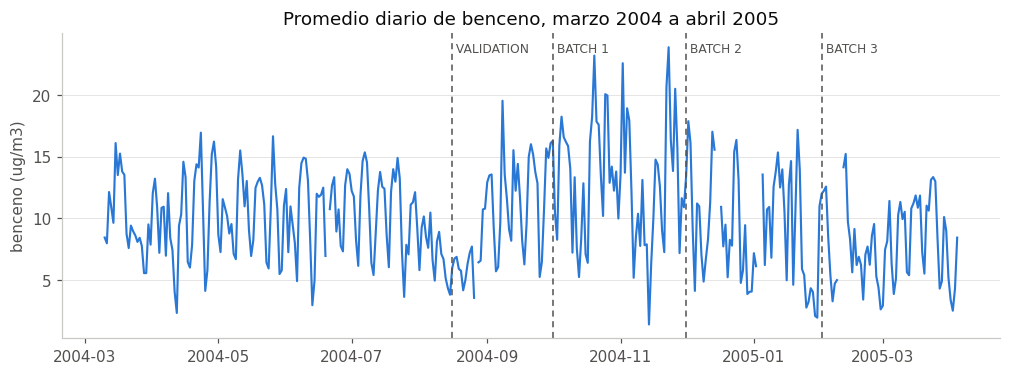

In [2]:
_ = plots.serie_completa(df)

**Que se ve:** el nivel no es parejo a lo largo del año. El tramo de entrenamiento (marzo a
agosto de 2004) se mueve alrededor de 10 ug/m3, BATCH 1 (octubre y noviembre) sube a 13, y para
BATCH 3 (febrero a abril de 2005) baja a 8. Ademas se nota que la variacion diaria es enorme
comparada con el promedio.

**Decision que cambia:** confirmamos el corte temporal. Los primeros meses son REFERENCE
(entrenamiento y validacion) y los ultimos son los tres lotes de "produccion". No es un corte
arbitrario: son tramos que de verdad se ven distintos, asi que sirven para probar si el sistema
detecta el cambio. Tambien queda claro que **partir los datos al azar seria un error**: mezclariamos
invierno con verano y el modelo veria el futuro.

---
## 2. Como se reparte el benceno

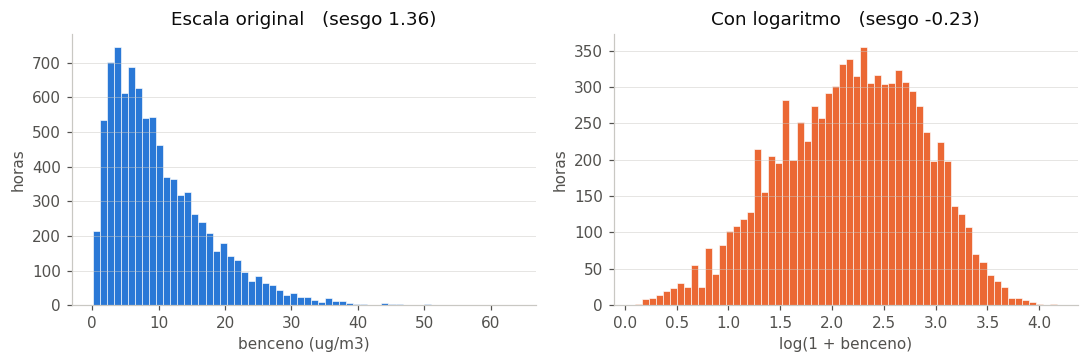

In [3]:
_ = plots.distribucion_target(df)

In [4]:
s = df[config.TARGET].dropna()
print(f"minimo {s.min():.2f}   mediana {s.median():.2f}   maximo {s.max():.2f}")
print(f"sesgo en escala original : {s.skew():.3f}")
print(f"sesgo con logaritmo      : {np.log1p(s).skew():.3f}")

minimo 0.10   mediana 8.20   maximo 63.70
sesgo en escala original : 1.361
sesgo con logaritmo      : -0.234


**Que se ve:** en la escala original hay muchisimas horas con valores bajos y una cola larga hacia
la derecha con picos de hasta 63.7. El sesgo es 1.361. Con logaritmo la forma se vuelve casi
simetrica y el sesgo baja a -0.234.

**Decision que cambia:** entrenamos sobre el logaritmo del benceno. Sin transformar, el modelo
gasta casi todo su esfuerzo en acertarle a los picos raros y falla en las horas normales. Las
metricas igual las vamos a reportar en ug/m3, deshaciendo el logaritmo, para que se entiendan.

---
## 3. El dia tiene forma

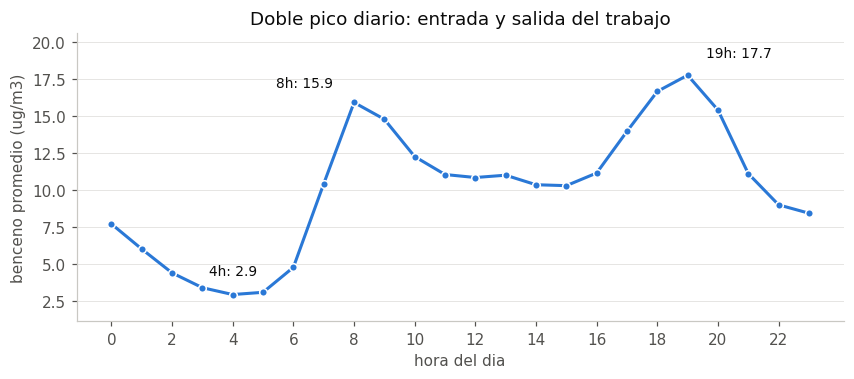

In [5]:
_ = plots.perfil_horario(df)

In [6]:
h = df.set_index("datetime")[config.TARGET].groupby(lambda x: x.hour).mean()
print(f"pico de la mañana : {h.loc[8]:.2f} a las 8h")
print(f"pico de la tarde  : {h.max():.2f} a las {h.idxmax()}h")
print(f"valle             : {h.min():.2f} a las {h.idxmin()}h")
print(f"el pico es {h.max()/h.min():.1f} veces el valle")

pico de la mañana : 15.89 a las 8h
pico de la tarde  : 17.74 a las 19h
valle             : 2.92 a las 4h
el pico es 6.1 veces el valle


**Que se ve:** dos picos claros, a las 8 de la mañana (15.9) y a las 7 de la noche (17.7), y un
valle a las 4 de la madrugada (2.9). El pico es **6.1 veces** el valle. Es el trafico: la gente entrando
y saliendo del trabajo.

**Decision que cambia:** la hora del dia tiene que ser una variable del modelo. Pero no como numero
del 0 al 23, porque asi el modelo cree que las 23h y las 0h estan lejisimos cuando en realidad son
consecutivas. La vamos a meter como seno y coseno, que es la forma de decirle a un modelo que el
dia es un circulo.

---
## 4. La semana tambien

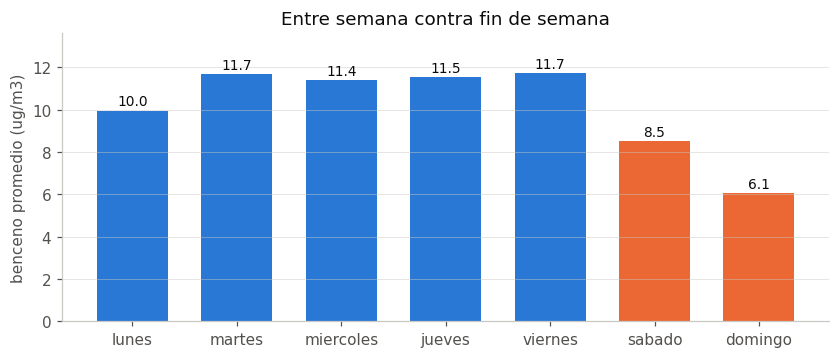

In [7]:
_ = plots.perfil_semanal(df)

In [8]:
d = df.set_index("datetime")[config.TARGET].groupby(lambda x: x.dayofweek).mean()
print(f"entre semana   : {d[:5].mean():.2f}")
print(f"fin de semana  : {d[5:].mean():.2f}")
print(f"diferencia     : {(d[5:].mean()/d[:5].mean()-1)*100:+.1f}%")

entre semana   : 11.26
fin de semana  : 7.28
diferencia     : -35.4%


**Que se ve:** de lunes a viernes el promedio es 11.26 y el fin de semana 7.28, un **35% menos**.
El domingo es el dia mas limpio del año con 6.05.

**Decision que cambia:** agregamos el dia de la semana y una marca de fin de semana. Sin eso, el
modelo va a predecir de mas todos los domingos. Y esto tiene una consecuencia para el monitoreo
tambien: si algun dia llega un lote con la mezcla de dias cambiada, el error del modelo va a subir
sin que los datos se vean raros. Es un caso que hay que tener en cuenta en la parte 8.

---
## 5. Cuanto se parece la serie a si misma

Esta es la parte que decide que rezagos vamos a construir. Y trae una trampa.

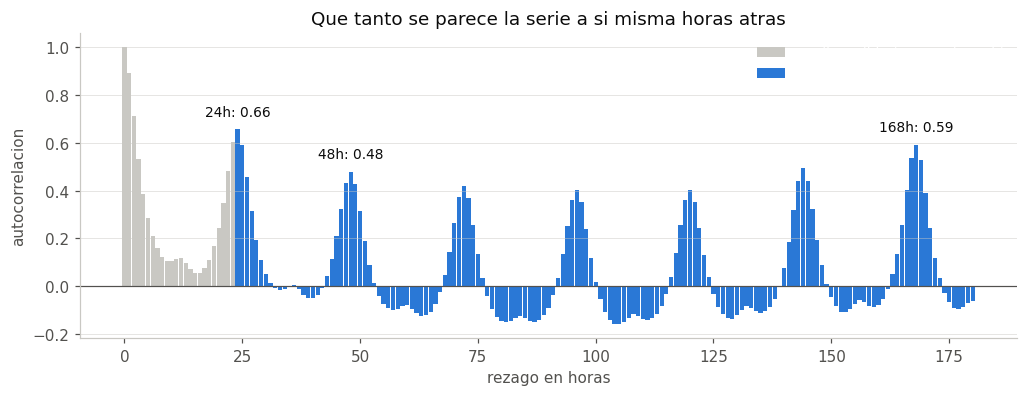

In [9]:
_ = plots.autocorrelacion(df)

In [10]:
from statsmodels.tsa.stattools import acf, adfuller

serie = np.log1p(df.set_index("datetime")[config.TARGET]).interpolate(limit_area="inside").dropna()
a = acf(serie, nlags=200, fft=True)
for L in [1, 2, 3, 24, 25, 48, 72, 168]:
    marca = "utilizable" if L >= config.FORECAST_HORIZON else "NO disponible a la hora t"
    print(f"  rezago {L:3d} h : {a[L]:6.3f}   {marca}")

prueba = adfuller(serie.values, autolag="AIC")
print(f"\nDickey-Fuller: estadistico {prueba[0]:.3f}, p-valor {prueba[1]:.2e}")
print("serie estacionaria" if prueba[1] < 0.05 else "serie NO estacionaria")

  rezago   1 h :  0.891   NO disponible a la hora t
  rezago   2 h :  0.711   NO disponible a la hora t
  rezago   3 h :  0.533   NO disponible a la hora t
  rezago  24 h :  0.656   utilizable
  rezago  25 h :  0.592   utilizable
  rezago  48 h :  0.479   utilizable
  rezago  72 h :  0.421   utilizable
  rezago 168 h :  0.592   utilizable

Dickey-Fuller: estadistico -10.528, p-valor 9.31e-19
serie estacionaria


**Que se ve:** la autocorrelacion mas alta esta en el rezago de 1 hora (0.891). Y ahi esta la trampa:
**ese rezago no lo podemos usar.** Estamos pronosticando 24 horas hacia adelante, asi que parados en
la hora t no sabemos nada de lo que pasa entre t+1 y t+23. Todo lo que este por debajo de 24 horas
esta pintado en gris en el grafico justamente por eso.

De lo que si podemos usar, lo mejor es el rezago de **24 horas (0.656)** y el de **168 horas
(0.592)**, que es exactamente una semana. Los picos del grafico se repiten cada 24 horas, y el mas
alto de todos los lejanos cae en 168.

El test de Dickey-Fuller da un p-valor practicamente cero, asi que la serie es estacionaria y no hay
que diferenciarla.

**Decision que cambia:** los rezagos que vamos a construir son **24, 25, 48 y 168 horas**, mas medias
moviles. Ninguno menor a 24. Esta es la regla que nos protege del leakage y es la misma razon por la
que el sensor PT08.S2, que correlaciona 0.982 con el benceno, solo puede entrar rezagado.

---
## 6. Que sirve de verdad para predecir

En vez de suponer, medimos: comparamos cada candidato contra el benceno de dentro de 24 horas,
usando **solo informacion disponible en el momento de predecir**.

In [11]:
d = df.set_index("datetime")
y = np.log1p(d[config.TARGET])
objetivo = y.shift(-config.FORECAST_HORIZON)   # lo que queremos: y(t+24)

candidatos = {
    "benceno ahora": y,
    "benceno hace 1 h": y.shift(1),
    "benceno hace 24 h": y.shift(24),
    "benceno hace 1 semana": y.shift(144),
    "media ultimas 3 h": y.rolling(3).mean(),
    "media ultimas 24 h": y.rolling(24).mean(),
    "sensor PT08.S2 ahora": np.log1p(d["PT08.S2(NMHC)"]),
    "temperatura": d["T"],
    "humedad relativa": d["RH"],
    "hora del dia": pd.Series(d.index.hour, index=d.index),
}

ranking = {}
for nombre, serie in candidatos.items():
    juntos = pd.concat([objetivo, serie], axis=1).dropna()
    ranking[nombre] = np.corrcoef(juntos.iloc[:, 0], juntos.iloc[:, 1])[0, 1]

ranking = pd.Series(ranking).sort_values(key=abs, ascending=False)
print(ranking.round(4).to_string())

benceno ahora            0.6728
sensor PT08.S2 ahora     0.6726
benceno hace 1 semana    0.6533
media ultimas 3 h        0.6173
benceno hace 1 h         0.6056
benceno hace 24 h        0.5051
hora del dia             0.4222
temperatura              0.2499
media ultimas 24 h       0.2231
humedad relativa        -0.1957


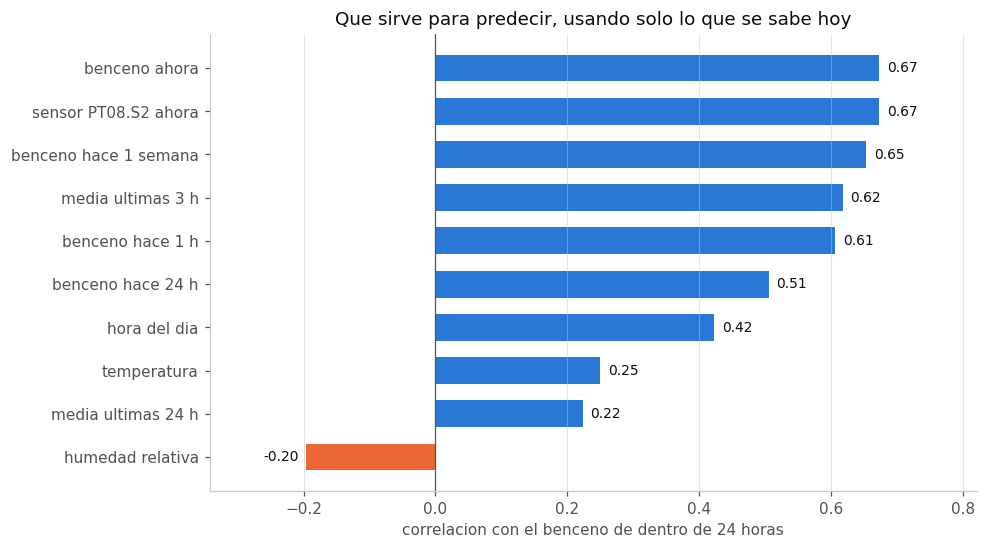

In [12]:
_ = plots.ranking_predictores(ranking)

**Que se ve:** el mejor predictor es el propio benceno de ahora (0.67), empatado con el sensor
PT08.S2 de ahora (0.67). Lo interesante es el tercero: **el benceno de hace una semana (0.65)** casi
iguala al de ahora. Eso confirma lo del grafico anterior.

La media de las ultimas 3 horas (0.62) le gana a la de 24 horas (0.22), asi que la ventana corta
sirve y la larga casi no aporta. La temperatura aporta poco (0.25) y la humedad va en contra (-0.20).

**Decision que cambia:** con esto queda armada la lista de variables para la parte 4:

| Variable | Por que |
|---|---|
| Rezagos 24, 25, 48 y 168 h del benceno | Los que la autocorrelacion y esta tabla senalan |
| Medias moviles de 3 y 24 h | La de 3 h aporta bastante; la de 24 se prueba y se descarta si no suma |
| Rezago 24 h de PT08.S2, S1 y S5 | Los sensores mas relacionados, siempre rezagados |
| Hora del dia en seno y coseno | Por el doble pico del analisis 3 |
| Dia de la semana y marca de fin de semana | Por la caida del 35% del analisis 4 |
| Temperatura y humedad rezagadas | Aportan poco pero son gratis y ayudan en los cambios de estacion |

Y algo que **no** va: ninguna variable del mismo instante que queremos predecir.

---
## 7. Los datos de produccion no se parecen a los de entrenamiento

Este analisis es el puente con el monitoreo.

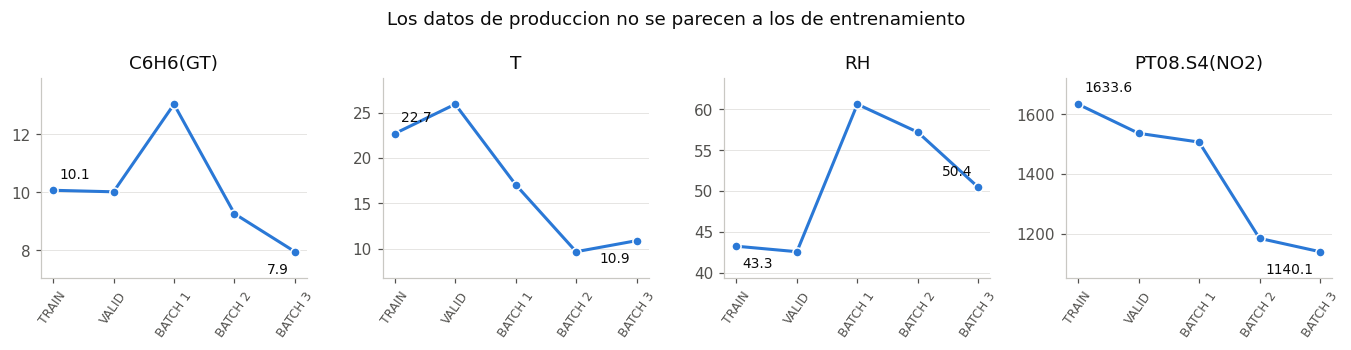

In [13]:
_ = plots.comparacion_tramos(df)

In [14]:
tramos = {
    "TRAIN":   (config.SPLIT_TRAIN_START,  config.SPLIT_VALID_START),
    "VALID":   (config.SPLIT_VALID_START,  config.SPLIT_BATCH1_START),
    "BATCH 1": (config.SPLIT_BATCH1_START, config.SPLIT_BATCH2_START),
    "BATCH 2": (config.SPLIT_BATCH2_START, config.SPLIT_BATCH3_START),
    "BATCH 3": (config.SPLIT_BATCH3_START, "2005-12-31"),
}
d = df.set_index("datetime")
resumen = []
for nombre, (desde, hasta) in tramos.items():
    tramo = d.loc[(d.index >= desde) & (d.index < hasta)]
    resumen.append({
        "tramo": nombre,
        "filas": len(tramo),
        "benceno": round(tramo[config.TARGET].mean(), 2),
        "T": round(tramo["T"].mean(), 1),
        "RH": round(tramo["RH"].mean(), 1),
        "PT08.S4": round(tramo["PT08.S4(NO2)"].mean(), 1),
    })
resumen = pd.DataFrame(resumen)
print(resumen.to_string(index=False))

referencia = d.loc[(d.index >= config.SPLIT_TRAIN_START) & (d.index < config.SPLIT_BATCH1_START)]
ultimo = d.loc[d.index >= config.SPLIT_BATCH3_START]
print("\nCambio de REFERENCE a BATCH 3:")
for c in [config.TARGET, "T", "RH", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)"]:
    antes, despues = referencia[c].mean(), ultimo[c].mean()
    print(f"  {c:16s} {antes:8.2f} -> {despues:8.2f}   ({(despues/antes-1)*100:+6.1f}%)")

  tramo  filas  benceno    T   RH  PT08.S4
  TRAIN   3798    10.07 22.7 43.3   1633.6
  VALID   1104    10.01 25.9 42.6   1536.4
BATCH 1   1464    13.03 17.1 60.6   1506.9
BATCH 2   1488     9.26  9.7 57.2   1184.8
BATCH 3   1503     7.95 10.9 50.4   1140.1

Cambio de REFERENCE a BATCH 3:
  C6H6(GT)            10.05 ->     7.95   ( -20.9%)
  T                   23.39 ->    10.88   ( -53.5%)
  RH                  43.11 ->    50.45   ( +17.0%)
  PT08.S2(NMHC)      944.41 ->   857.42   (  -9.2%)
  PT08.S3(NOx)       888.90 ->   755.37   ( -15.0%)
  PT08.S4(NO2)      1612.34 ->  1140.15   ( -29.3%)


**Que se ve:** entre REFERENCE y BATCH 3 la temperatura cae de 23.4 a 10.9 grados (**-53.5%**), la
humedad sube 17%, y el sensor PT08.S4 baja de 1612 a 1140 (**-29.3%**). El benceno baja 20.9%.

Son dos cosas distintas mezcladas y conviene separarlas:

1. **Cambio estacional real.** Los datos van de primavera a invierno en el norte de Italia. La
   temperatura y la humedad cambian porque el clima cambio, no porque el sensor este malo.
2. **Posible deriva del sensor.** La caida del 29% de PT08.S4 es demasiado grande para explicarse
   solo por la estacion. Estos sensores de estado solido se descalibran con el uso.

**Decision que cambia:** no hay que simular ningun drift artificial, **el dataset ya lo trae**. Para
la parte 8 vamos a comparar cada lote contra REFERENCE con PSI. Y anotamos desde ya la pregunta
importante que pide el enunciado: que la distribucion cambie **no significa** que el modelo se haya
dañado. Si el modelo aprendio la relacion entre temperatura y benceno, un invierno frio entra dentro
de lo que ya sabe. Por eso el disparador de reentrenamiento va a exigir **las dos cosas a la vez**:
drift en los datos **y** caida del desempeño.

---
## Resumen de las decisiones

| # | Analisis | Decision |
|---|---|---|
| 1 | Serie completa | Corte temporal por fecha, nunca al azar |
| 2 | Distribucion | Entrenar sobre el logaritmo, reportar en ug/m3 |
| 3 | Perfil horario | Hora del dia como seno y coseno |
| 4 | Perfil semanal | Dia de la semana y marca de fin de semana |
| 5 | Autocorrelacion | Rezagos de 24, 25, 48 y 168 h. Ninguno menor a 24 |
| 6 | Ranking de predictores | Lista final de variables, todas rezagadas |
| 7 | Comparacion de tramos | El drift ya existe; el disparador exige drift **y** caida de desempeño |

Las figuras quedaron guardadas en `reports/figuras/` para reusarlas en el informe y en MLflow.